# Benchmarking tile generation

This notebook walks through **benchmarking performance** of [TiTiler-CMR](https://github.com/developmentseed/titiler-cmr) for a given Earthdata CMR dataset.

**In this notebook, you'll learn**:

- How to benchmark tile rendering performance across zoom levels
- What factors impact tile generation performance in TiTiler-CMR.

In [ ]:
import os

import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D


from datacube_benchmark import (
    DatasetParams,
    benchmark_viewport,
    tiling_benchmark_summary,
)

## TiTiler-CMR

For this walkthrough, we will use the Titiler-CMR staging endpoint https://staging.openveda.cloud/api/titiler-cmr/.

Titiler-CMR supports two different backends:
  - **xarray** → for gridded/cloud-native datasets (e.g., NetCDF4/HDF5/GRIB), typically exposed as variables.
  - **rasterio** → for COG/raster imagery-style datasets exposed as bands (optionally via a regex).


> **Tip: Explore data granules with `earthaccess`**
> 
> You can use [`earthaccess`](https://github.com/nsidc/earthaccess) to search and inspect the individual granules used in your query. This helps you validate which files were accessed, their sizes, and the temporal range.

In [ ]:
concept_id = "C2723754864-GES_DISC"
time_range = ("2022-03-01T00:00:01Z", "2022-03-02T23:59:59Z")

# Authenticate if needed
earthaccess.login()  # or use "interactive" if needed

results = earthaccess.search_data(concept_id=concept_id, temporal=time_range)

print(f"Found {len(results)} granules between {time_range[0]} and {time_range[1]}")

Found 2 granules between 2022-03-01T00:00:01Z and 2022-03-02T23:59:59Z


## Tile Generation Benchmarking
We are going to measure the tile generation performance across different zoom levels using `titiler_cmr_benchmark.benchmark_viewport` function. 
This function simulates the load of a typical viewport render in a slippy map, where multiple adjacent tiles must be fetched in parallel to draw a single view.


### Step 1: Specify API Parameters

First, we have to define the parameters for the CMR dataset we want to benchmark. The `DatasetParams` class encapsulates all the necessary information to interact with a specific dataset via TiTiler-CMR.

Note this first example is for a dataset where each file has global coverage. This is important to evaluating the results of benchmarking.


In [ ]:
endpoint = os.getenv("TITILER_CMR_ENDPOINT", "https://openveda.cloud/api/titiler-cmr")

ds_xarray = DatasetParams(
    concept_id="C2723754864-GES_DISC",
    backend="xarray",
    datetime_range="2022-04-01T00:00:01Z/2022-04-02T23:59:59Z",
    variable="precipitation",
    step="P1D",
    temporal_mode="point",
)

### Step 2: Specifiy Zoom Levels
Zoom levels determine the detail and extent of the area being rendered.  At lower zoom levels, a single tile covers a large spatial area and may intersect many granules. This usually translates to more I/O, more resampling/mosaic work, higher latency, and higher chance of timeouts errors.

As you increase the zoom level, each tile covers a smaller area, reducing the number of intersecting granules and the amount of work per request. 

We'll define a range of zoom levels to test to see how performance varies.

In [5]:
min_zoom = 3
max_zoom = 20

# Define the viewport parameters
viewport_width = 4
viewport_height = 4
lng = 25.0
lat = 29.0

### Step 3: Run the Benchmark

Now, let's run the benchmark across the specified zoom levels and visualize the results.

Under the hood, `benchmark_viewport` computes the center tile for each zoom level, selects its neighboring tiles to approximate a viewport, and requests them concurrently from the TiTiler-CMR endpoint. This function returns a pandas.DataFrame containing the response times for each tile request.


In [6]:
df_viewport = await benchmark_viewport(
    endpoint=endpoint,
    dataset=ds_xarray,
    lng=lng,
    lat=lat,
    viewport_width=viewport_width,
    viewport_height=viewport_height,
    min_zoom=min_zoom,
    max_zoom=max_zoom,
    timeout_s=60.0,
)

=== TiTiler-CMR Tile Benchmark ===
Client: 12 physical / 12 logical cores | RAM: 24.00 GiB
Dataset: C2723754864-GES_DISC (xarray)
Query params: 8 parameters
  concept_id: C2723754864-GES_DISC
  backend: xarray
  datetime: 2022-03-01T00:00:01Z/2022-03-01T23:59:59Z
  variable: precipitation
  step: P1D
  temporal_mode: point
  tile_format: png
  tile_scale: 1
Total execution time: 19.568s


In [7]:
df_viewport.head()

,zoom,x,y,status_code,ok,no_data,is_error,response_time_sec,content_type,response_size_bytes,url,error_text,total_run_elapsed_s
0,3,2,1,200,True,False,False,0.905818,image/png,694,https://staging.openveda.cloud/api/titiler-cmr...,None,19.567708
1,3,3,1,200,True,False,False,0.895378,image/png,694,https://staging.openveda.cloud/api/titiler-cmr...,None,19.567708
2,3,4,1,200,True,False,False,0.990423,image/png,694,https://staging.openveda.cloud/api/titiler-cmr...,None,19.567708
3,3,5,1,200,True,False,False,0.972824,image/png,694,https://staging.openveda.cloud/api/titiler-cmr...,None,19.567708
4,3,6,1,200,True,False,False,0.995508,image/png,694,https://staging.openveda.cloud/api/titiler-cmr...,None,19.567708


The output includes the following columns:
 
- `zoom, x, y` — XYZ tile indices
- `status_code` — HTTP code (200 = success, 204 = no-data, 4xx/5xx = errors)
- `response_time_sec` — wall time in seconds
- `response_size_bytes` — payload size
- `ok`, `is_error, has_data` — convenience flags

Now, let's use a convenience function to summarize the benchmark results. 

In [ ]:
df_summary = tiling_benchmark_summary(df_viewport)
df_summary.head()

,zoom,n_tiles,ok_pct,no_data_pct,error_pct,median_latency_s,p95_latency_s
0,3,25.0,100.0,0.0,0.0,1.012640,5.310309
1,4,25.0,100.0,0.0,0.0,0.963664,1.944906
2,5,25.0,100.0,0.0,0.0,0.962649,5.287413
3,6,25.0,100.0,0.0,0.0,0.915212,5.460520
4,7,25.0,100.0,0.0,0.0,0.990444,5.042200
5,8,25.0,100.0,0.0,0.0,0.913841,6.558917
6,9,25.0,100.0,0.0,0.0,1.026332,6.428394
7,10,25.0,100.0,0.0,0.0,1.022140,5.241293
8,11,25.0,100.0,0.0,0.0,0.972776,1.226558
9,12,25.0,100.0,0.0,0.0,1.002469,1.412412


### Step 4: Plot the results

You may notice there is little variation in performance across zoom levels. This collection's files have global extent. Regardless of the zoom level of the tile request, the same file or files must be opened and read. (Multiple files in the case that the datetime parameter returns multiple granules).

This situation is in contrast to the next example which uses files without global extent.

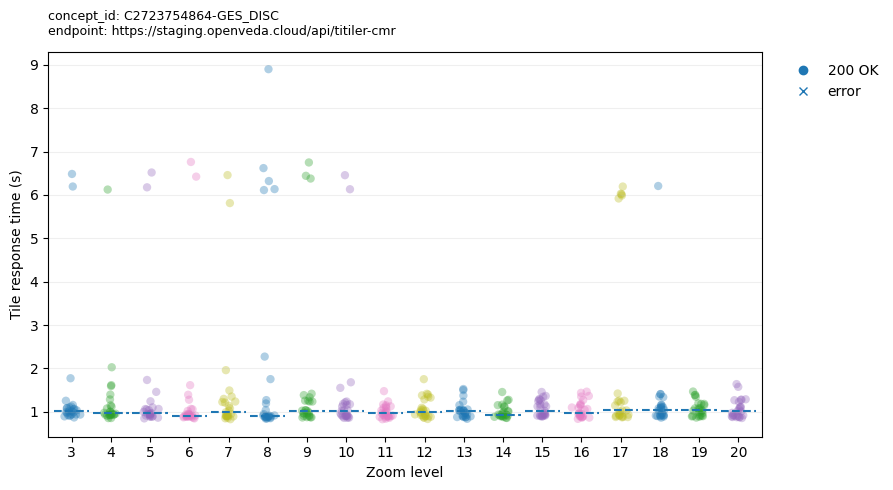

In [ ]:
def summarize_and_plot_tiles_from_df(
    df: pd.DataFrame,
    *,
    jitter=0.08,
    alpha=0.35,
    figsize=(9, 5),
    title_lines=None,
):
    """Generate summary and plot from tile benchmark DataFrame."""
    summary = tiling_benchmark_summary(df)

    fig, ax = plt.subplots(figsize=figsize)
    fig.subplots_adjust(right=0.72, top=0.80)

    zoom_levels = sorted(
        int(z) for z in pd.to_numeric(df["zoom"], errors="coerce").dropna().unique()
    )
    ax.set_xticks(zoom_levels)
    if zoom_levels:
        ax.set_xlim(min(zoom_levels) - 0.6, max(zoom_levels) + 0.6)

    for z in zoom_levels:
        sub = df[df["zoom"] == z]
        if sub.empty:
            continue

        x = np.random.normal(loc=z, scale=jitter, size=len(sub))
        ok_mask = sub["ok"].astype(bool).values
        err_mask = sub["is_error"].astype(bool).values

        ax.scatter(
            x[ok_mask],
            sub.loc[ok_mask, "response_time_sec"],
            alpha=alpha,
            edgecolor="none",
            label=None,
        )
        ax.scatter(
            x[err_mask],
            sub.loc[err_mask, "response_time_sec"],
            marker="x",
            alpha=min(0.85, alpha + 0.25),
            label=None,
        )

        med = pd.to_numeric(sub["response_time_sec"], errors="coerce").median()
        if np.isfinite(med):
            ax.hlines(med, z - 0.45, z + 0.45, linestyles="--")

    ax.set_xlabel("Zoom level")
    ax.set_ylabel("Tile response time (s)")

    ok_proxy = Line2D([], [], linestyle="none", marker="o", label="200 OK")
    err_proxy = Line2D(
        [], [], linestyle="none", marker="x", label="error (≥400 or failure)"
    )
    ax.legend(
        [ok_proxy, err_proxy],
        ["200 OK", "error"],
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
    )

    if title_lines:
        ax.set_title("\n".join(title_lines), fontsize=9, loc="left", pad=12)

    ax.grid(True, axis="y", alpha=0.2)
    plt.tight_layout()

    return summary, (fig, ax)


summary, (fig, ax) = summarize_and_plot_tiles_from_df(
    df_viewport,
    title_lines=[
        "concept_id: C2723754864-GES_DISC",
        "endpoint: https://openveda.cloud/api/titiler-cmr",
    ],
)
plt.show()

### HLS Example

In this example, we will benchmark a CMR dataset that is structured as Cloud-Optimized GeoTIFFs (COGs) with individual bands. We will use the `rasterio` backend for this dataset.

In contrast to the first example, HLS is much higher spatial resolution (30 meters vs 0.1 degrees)and each granule has a small spatial footprint. In general, the lower the zoom level (more zoomed out), the more files need to be opened to render a tile, which can lead to increased latency.

A more in-depth HLS benchmark report is provided in the [Harmonized Landsat Sentinel 2 (HLS): tiling configuration and rendering performance](./hls_tiling) documentation.

In [10]:
ds_hls_day = DatasetParams(
    concept_id="C2021957295-LPCLOUD",
    backend="rasterio",
    datetime_range="2023-10-01T00:00:01Z/2023-10-07T00:00:01Z",
    bands=["B04", "B03", "B02"],
    bands_regex="B[0-9][0-9]",
    step="P1D",
    temporal_mode="point",
)
ds_hls_week = DatasetParams(
    concept_id="C2021957657-LPCLOUD",
    backend="rasterio",
    datetime_range="2023-10-01T00:00:01Z/2023-10-20T00:00:01Z",
    bands=["B04", "B03", "B02"],
    bands_regex="B[0-9][0-9]",
    step="P1W",
    temporal_mode="point",
)

min_zoom = 3
max_zoom = 20
viewport_width = 3
viewport_height = 3
timeout_s = 60.0

In [ ]:
df_viewport_day = await benchmark_viewport(
    endpoint=endpoint,
    dataset=ds_hls_day,
    lng=lng,
    lat=lat,
    viewport_width=viewport_width,
    viewport_height=viewport_height,
    min_zoom=min_zoom,
    max_zoom=max_zoom,
    timeout_s=timeout_s,
)

df_viewport_day_summary = tiling_benchmark_summary(df_viewport_day)
df_viewport_day_summary.head()

=== TiTiler-CMR Tile Benchmark ===
Client: 12 physical / 12 logical cores | RAM: 24.00 GiB
Dataset: C2021957295-LPCLOUD (rasterio)
Query params: 11 parameters
  concept_id: C2021957295-LPCLOUD
  backend: rasterio
  datetime: 2023-10-01T00:00:01Z/2023-10-07T00:00:01Z
  bands: B04
  bands: B03
  bands: B02
  bands_regex: B[0-9][0-9]
  step: P1D
  temporal_mode: point
  tile_format: png
  tile_scale: 1
Total execution time: 28.973s


,zoom,n_tiles,ok_pct,no_data_pct,error_pct,median_latency_s,p95_latency_s
0,3,9.0,100.0,0.0,0.0,20.260291,22.953679
1,4,9.0,100.0,0.0,0.0,14.811281,16.109941
2,5,9.0,100.0,0.0,0.0,14.647920,15.630529
3,6,9.0,100.0,0.0,0.0,9.515119,14.123920
4,7,9.0,100.0,0.0,0.0,4.927403,6.544323
5,8,9.0,100.0,0.0,0.0,1.892685,3.507236
6,9,9.0,100.0,0.0,0.0,1.276321,1.905843
7,10,9.0,100.0,0.0,0.0,1.301266,1.758872
8,11,9.0,100.0,0.0,0.0,1.041721,1.571191
9,12,9.0,100.0,0.0,0.0,0.836667,1.103613


In [ ]:
df_viewport_week = await benchmark_viewport(
    endpoint=endpoint,
    dataset=ds_hls_week,
    lng=lng,
    lat=lat,
    viewport_width=viewport_width,
    viewport_height=viewport_height,
    min_zoom=min_zoom,
    max_zoom=max_zoom,
    timeout_s=timeout_s,
)

df_viewport_week_summary = tiling_benchmark_summary(df_viewport_week)
df_viewport_week_summary.head()

=== TiTiler-CMR Tile Benchmark ===
Client: 12 physical / 12 logical cores | RAM: 24.00 GiB
Dataset: C2021957657-LPCLOUD (rasterio)
Query params: 11 parameters
  concept_id: C2021957657-LPCLOUD
  backend: rasterio
  datetime: 2023-10-01T00:00:01Z/2023-10-20T00:00:01Z
  bands: B04
  bands: B03
  bands: B02
  bands_regex: B[0-9][0-9]
  step: P1W
  temporal_mode: point
  tile_format: png
  tile_scale: 1
Total execution time: 33.096s


,zoom,n_tiles,ok_pct,no_data_pct,error_pct,median_latency_s,p95_latency_s
0,3,9.0,100.0,0.0,0.0,18.116566,20.606391
1,4,9.0,100.0,0.0,0.0,14.008781,18.298877
2,5,9.0,100.0,0.0,0.0,13.031852,13.886532
3,6,9.0,100.0,0.0,0.0,12.995484,15.004291
4,7,9.0,100.0,0.0,0.0,7.296406,8.000774
5,8,9.0,100.0,0.0,0.0,3.012904,4.451006
6,9,9.0,100.0,0.0,0.0,1.738529,2.842115
7,10,9.0,100.0,0.0,0.0,1.543565,4.875392
8,11,9.0,100.0,0.0,0.0,1.250630,4.248518
9,12,9.0,100.0,0.0,0.0,1.021125,1.168851


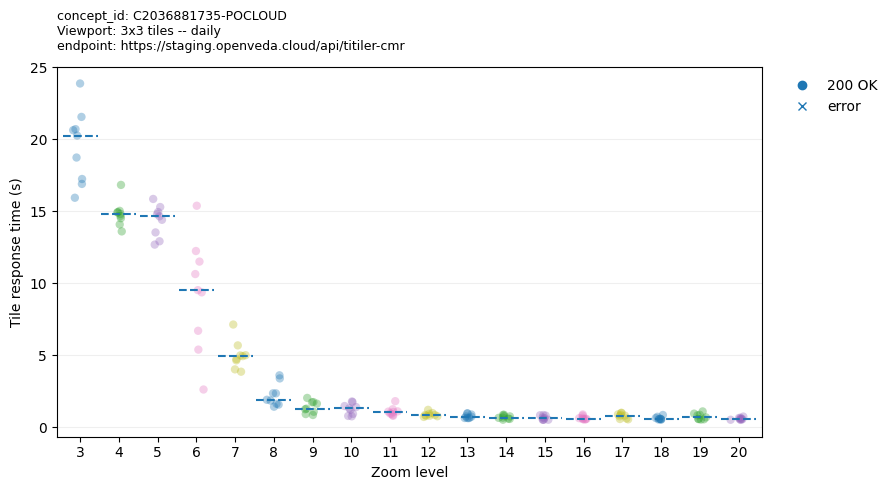

In [13]:
summary, (fig, ax) = summarize_and_plot_tiles_from_df(
    df_viewport_day,
    title_lines=[
        "concept_id: C2036881735-POCLOUD",
        "Viewport: 3x3 tiles -- daily",
        "endpoint: https://openveda.cloud/api/titiler-cmr",
    ],
)

plt.show()

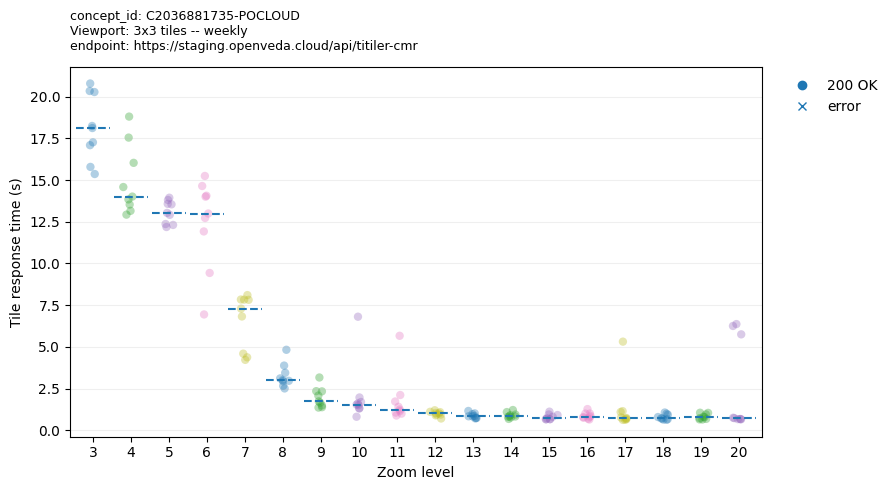

In [14]:
summary, (fig, ax) = summarize_and_plot_tiles_from_df(
    df_viewport_week,
    title_lines=[
        "concept_id: C2036881735-POCLOUD",
        "Viewport: 3x3 tiles -- weekly",
        "endpoint: https://openveda.cloud/api/titiler-cmr",
    ],
)

plt.show()

## Conclusion

In this notebook, we explored how to check the performance of tile rendering performance in TiTiler-CMR using different datasets and backends. We observed how factors such as zoom levels, temporal intervals, and dataset structures impact the latency of tile requests.

In general, performance depends on:
- zoom level and spatial resolution of the dataset
- the width of the datetime interval and the temporal resolution of the dataset
- how many granules intersect the tile footprint

Takeaways: 
- Consider specifying a minzoom and maximum datetime interval given a specific datasets temporal and spatial resolution.


### Further Reading
- [Tile Matrix Sets and Zoom Levels](https://docs.opengeospatial.org/is/17-083r2/17-083r2.html#_tile_matrix_sets_and_zoom_levels)
- [Earthdata Cloud CMR Datasets](https://cmr.earthdata.nasa.gov/search/site/docs/search/api.html#datasets)
